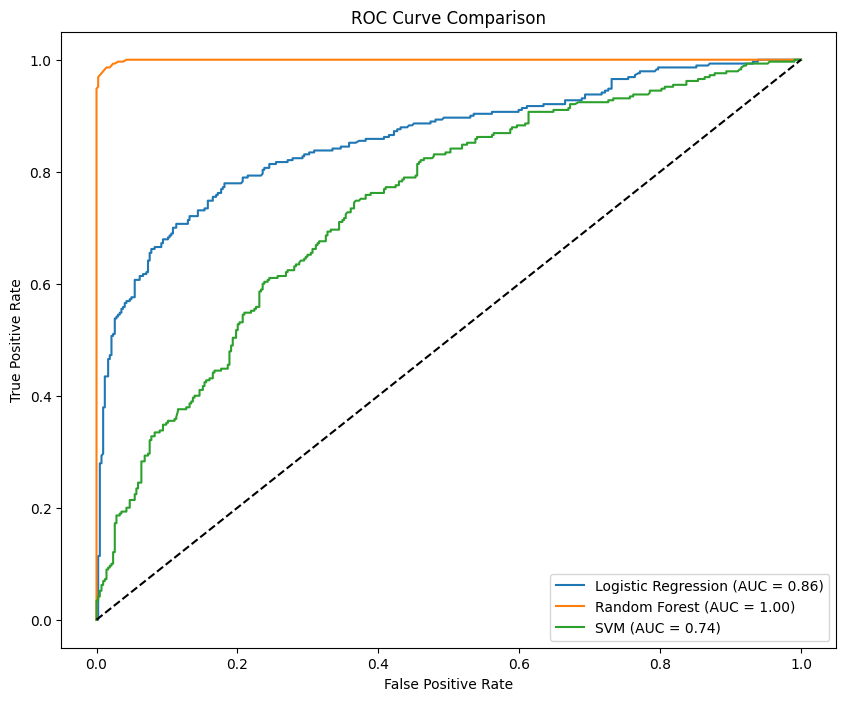

                     fit_time  score_time  test_accuracy  test_precision  \
Logistic Regression  0.058178    0.018174       0.802445        0.785805   
Random Forest        0.275776    0.032493       0.792762        0.755176   
SVM                  0.096051    0.026172       0.665141        0.688100   

                     test_recall   test_f1  test_roc_auc  
Logistic Regression     0.713793  0.745259      0.856076  
Random Forest           0.727586  0.739025      0.850015  
SVM                     0.337931  0.450315      0.727901  


In [1]:
import pandas as pd
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Persiapan Dataset (Titanic)
df = sns.load_dataset('titanic')
df = df[['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']].dropna()
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
X = df.drop('survived', axis=1)
y = df['survived']

# 2. Definisi Model
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(),
    "SVM": SVC(probability=True)
}

# 3. Evaluasi dengan Stratified 10-Fold CV
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1',
    'roc_auc': 'roc_auc'
}

results = {}
plt.figure(figsize=(10, 8))

for name, model in models.items():
    # Menghitung metrik CV
    cv_results = cross_validate(model, X, y, cv=cv, scoring=scoring)
    results[name] = {k: v.mean() for k, v in cv_results.items()}
    
    # Plot ROC (menggunakan rata-rata untuk visualisasi)
    model.fit(X, y)
    y_prob = model.predict_proba(X)[:, 1]
    fpr, tpr, _ = roc_curve(y, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc(fpr, tpr):.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend()
plt.show()

# 4. Tampilkan Hasil
print(pd.DataFrame(results).T)